<a href="https://colab.research.google.com/github/comet-toolkit/comet_training/blob/main/punpy_exercise_spectrometer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Training Session — CoMet Toolkit: Uncertainties Made Easy**

# Exercise: From Spectrometer Measurements to NDVI with Uncertainty Propagation

## Overview

This exercise demonstrates how to propagate uncertainties through a complete measurement workflow, from raw spectrometer data to a vegetation index (NDVI).

In a lab session, repeated spectrometer measurements were taken for three surface targets:
- **Astro-turf**
- **Cress**
- **Sand**
- **Spectralon reference panel** (for calibration)

All targets were illuminated using the same lamp. The Spectralon panel, with its known reflectance spectrum, enables conversion from raw digital numbers (DN) to calibrated surface reflectance:

$$\rho_{\text{surface}}(\lambda) = \frac{DN_{\text{surface}}(\lambda)}{DN_{\text{panel}}(\lambda)} \rho_{\text{panel}}(\lambda)$$

## Learning Objectives

By the end of this exercise, you will be able to:
- Define measurement models in Python and propagate uncertainties through them
- Distinguish between random uncertainty (from measurement noise) and systematic uncertainty (from calibration)
- Use **punpy**'s Monte Carlo approach to propagate independent and correlated uncertainties
- Calculate derived quantities like reflectance spectra and vegetation indices with associated uncertainty
- Understand how uncertainties accumulate through a multi-step measurement workflow
- Perform spectral band aggregation and NDVI calculation with uncertainty propagation

## *Step 1* - Set up the Environment

First, install the required packages for uncertainty propagation and band integration:

In [1]:
!pip install punpy>=1.0.6 matheo

**If running in Google Colab:** Click `Runtime > Restart session` above to load the newly installed packages.  
**If running locally:** The kernel will use the packages automatically after installation.

Then import the required python packages:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import punpy
import xarray as xr
from matheo import band_integration

❗ **Note:** If any imports fail, restart the kernel/session and try again.

## *Step 2* - Load and Inspect the Measurement Data

### Data Description

The dataset contains repeated spectrometer measurements from 600–1000 nm for:
- **Spectralon** (for calibration purposes)
- **Astro-turf** (multiple repeats per target)
- **Cress** (multiple repeats per target)
- **Sand** (multiple repeats per target)

In [3]:
!git clone https://github.com/comet-toolkit/comet_training.git

fatal: destination path 'comet_training' already exists and is not an empty directory.


In [4]:
# Load datasets from NetCDF files
spectralon_ds = xr.load_dataset("comet_training/example_data/Spectralon.nc")
astroturf_ds = xr.load_dataset("comet_training/example_data/Astro_turf.nc")
cress_ds = xr.load_dataset("comet_training/example_data/Cress.nc")
sand_ds = xr.load_dataset("comet_training/example_data/Sand.nc")

# Load Spectralon reference reflectance
spectralon_ref_ds = xr.load_dataset("comet_training/example_data/spectralon_reflectance.nc")

The raw DN measurements must be normalised by integration time (the exposure duration of each measurement). This converts DN counts to a per-unit-time basis, making measurements comparable across different settings and reducing dependence on instrumental parameters.

In [5]:
# Extract wavelengths and digital number (DN) data
wavelength = spectralon_ds['wavelength'].values

# Normalise DN measurements by integration time to make them comparable across different measurement settings
# This converts raw DN counts to a per-unit-time basis
dn_panel_repeats = spectralon_ds['digital_number'].values / spectralon_ds.attrs['integration_time_ms']      # shape: (n_wavelength, n_panel_repeats)
dn_astroturf_repeats = astroturf_ds['digital_number'].values / astroturf_ds.attrs['integration_time_ms']     # shape: (n_wavelength, n_astroturf_repeats)
dn_cress_repeats = cress_ds['digital_number'].values / cress_ds.attrs['integration_time_ms']             # shape: (n_wavelength, n_cress_repeats)
dn_sand_repeats = sand_ds['digital_number'].values / sand_ds.attrs['integration_time_ms']               # shape: (n_wavelength, n_sand_repeats)

### Load Spectralon Reference Reflectance and Uncertainties

The Spectralon panel has a known reflectance spectrum from its calibration certificate, forming our reference. This data is loaded, interpolated to the measured wavelength grid (600–1000 nm), and wavelength-dependent uncertainties are extracted. 

These calibration uncertainties are systematic in nature - they apply equally to all measurements that use this panel for calibration.

In [6]:
# Load and interpolate Spectralon reflectance to measured wavelength grid
from scipy import interpolate

wavelength_ref = spectralon_ref_ds['wavelength'].values
reflectance_ref = spectralon_ref_ds['reflectance'].values

# Create linear interpolation function
f_interp = interpolate.interp1d(wavelength_ref, reflectance_ref, kind='linear', 
                                bounds_error=False, fill_value='extrapolate')

# Interpolate to measured wavelength grid
rho_panel = f_interp(wavelength)
# Create wavelength-dependent uncertainty for Spectralon reflectance (in %)
# Based on calibration certificate data
u_rho_panel_percent = np.zeros_like(wavelength)
u_rho_panel_percent[(wavelength >= 465) & (wavelength <= 780)] = 1.55
u_rho_panel_percent[(wavelength > 780) & (wavelength <= 1000)] = 2.60

# Convert uncertainty from percentage to absolute value
u_rho_panel = (u_rho_panel_percent / 100.0) * rho_panel

In [7]:
print("Panel repeats:", dn_panel_repeats.shape)
print("Astro-turf repeats:", dn_astroturf_repeats.shape)
print("Cress repeats:", dn_cress_repeats.shape)
print("Sand repeats:", dn_sand_repeats.shape)
print(f"\nSpectralon reflectance loaded:")
print(f"  Reference wavelength range: {wavelength_ref.min():.1f} - {wavelength_ref.max():.1f} nm")
print(f"  Interpolated to measured range: {wavelength.min():.2f} - {wavelength.max():.2f} nm")
print(f"  Panel reflectance range: {rho_panel.min():.4f} - {rho_panel.max():.4f}")
print(f"\nWavelength-dependent uncertainties:")
print(f"  465–780 nm:   0.55%")
print(f"  780–1000 nm:  1.60%")
print(f"  Absolute uncertainty range: {u_rho_panel.min():.6f} - {u_rho_panel.max():.6f}")

Panel repeats: (1718, 25)
Astro-turf repeats: (1718, 51)
Cress repeats: (1718, 77)
Sand repeats: (1718, 60)

Spectralon reflectance loaded:
  Reference wavelength range: 600.0 - 999.8 nm
  Interpolated to measured range: 600.01 - 999.85 nm
  Panel reflectance range: 0.9942 - 0.9950

Wavelength-dependent uncertainties:
  465–780 nm:   0.55%
  780–1000 nm:  1.60%
  Absolute uncertainty range: 0.015410 - 0.025865


### Inspect the Spectrometer Measurements
First, calculate the mean and standard deviation of the repeated DN measurements for each target.
The standard deviation of repeated measurements will be used to estimate the random measurement noise.

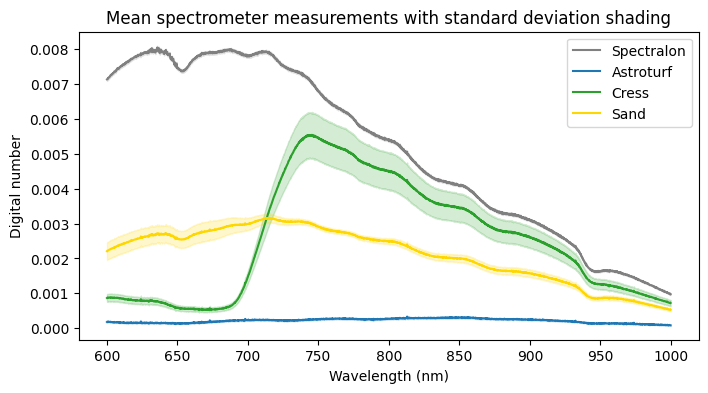

In [8]:
def calculate_stats(dn_repeats):
    """
    Calculate mean and standard deviation across repeated measurements.

    :param dn_repeats: repeated measurements array (shape: n_wavelengths × n_repeats)
    :returns: tuple of (mean, standard_deviation) arrays
    """
    mean = np.mean(dn_repeats, axis=1)
    std = np.std(dn_repeats, axis=1, ddof=1)
    return mean, std

# Calculate mean and std for each target
dn_panel_mean, dn_panel_std = calculate_stats(dn_panel_repeats)
dn_astroturf_mean, dn_astroturf_std = calculate_stats(dn_astroturf_repeats)
dn_cress_mean, dn_cress_std = calculate_stats(dn_cress_repeats)
dn_sand_mean, dn_sand_std = calculate_stats(dn_sand_repeats)

# Define consistent colours for surfaces (used throughout the notebook)
color_map = {"Spectralon": "gray", "Astroturf": "tab:blue", "Cress": "tab:green", "Sand": "gold"}

# Plot the DN measurement data with shaded uncertainty regions
plt.figure(figsize=(8, 4))
plt.plot(wavelength, dn_panel_mean, label="Spectralon", linewidth=1.5, color=color_map["Spectralon"])
plt.fill_between(wavelength, dn_panel_mean - dn_panel_std, dn_panel_mean + dn_panel_std, alpha=0.2, color=color_map["Spectralon"])

plt.plot(wavelength, dn_astroturf_mean, label="Astroturf", linewidth=1.5, color=color_map["Astroturf"])
plt.fill_between(wavelength, dn_astroturf_mean - dn_astroturf_std, dn_astroturf_mean + dn_astroturf_std, alpha=0.2, color=color_map["Astroturf"])

plt.plot(wavelength, dn_cress_mean, label="Cress", linewidth=1.5, color=color_map["Cress"])
plt.fill_between(wavelength, dn_cress_mean - dn_cress_std, dn_cress_mean + dn_cress_std, alpha=0.2, color=color_map["Cress"])

plt.plot(wavelength, dn_sand_mean, label="Sand", linewidth=1.5, color=color_map["Sand"])
plt.fill_between(wavelength, dn_sand_mean - dn_sand_std, dn_sand_mean + dn_sand_std, alpha=0.2, color=color_map["Sand"])

plt.xlabel("Wavelength (nm)")
plt.ylabel("Digital number")
plt.title("Mean spectrometer measurements with standard deviation shading")
plt.legend()
plt.show()

### Understanding the Uncertainty Sources

This exercise considers two main categories of uncertainty, distinguished by their **error correlation properties**:

**Random uncertainty:** Arises due to instrument noise (e.g., detector fluctuations)
- Varies independently with each measurement realisation
- Uncorrelated across repeated observations
- Sources: DN variation for each surface, DN variation for the Spectralon panel

**Systematic uncertainty:** Arises from calibration biases that persist across measurements
- Fully correlated across all wavelengths within the measurement set
- Example: If the Spectralon panel's true reflectance is uniformly 1% higher than its certificate states, this bias affects every wavelength identically
- Sources: Spectralon panel reflectance uncertainty (treated as fully wavelength-correlated)

Both uncertainty types propagate independently through each step in the measurement chain: **DN measurements + panel calibration → reflectance spectrum → band-integrated reflectance → NDVI**.

## *Step 3* - Define the Measurement Functions

### Processing Chain Overview

This exercise follows a complete measurement workflow with uncertainty propagation at each step:

**Raw Data → Calibrated Spectrum → Vegetation Index**

$$DN \text{ repeats} \; \rightarrow \; \text{mean/std} \; \rightarrow \; \text{reflectance spectrum} \; \rightarrow \; \text{red/NIR band} \; \rightarrow \; \text{NDVI} \; \rightarrow \; \text{NDVI uncertainty}$$

At each arrow, **both random and systematic uncertainties propagate independently** through the measurement model using Monte Carlo sampling. The final NDVI uncertainty combines all contributions from DN repeatability, reflectance calibration bias, and band integration.

Now we implement the three measurement models that will be used to transform raw DN measurements into a final NDVI value with uncertainties.

We use three mathematical models in this analysis:

**1. Surface Reflectance** (from DN measurements and panel calibration):
$$\rho_{\text{surface}}(\lambda) = \frac{DN_{\text{surface}}(\lambda)}{DN_{\text{panel}}(\lambda)} \rho_{\text{panel}}(\lambda)$$

In [9]:
def reflectance_model(dn_surface, dn_panel, rho_panel):
    """Calibrate surface reflectance from DN using reference panel."""
    return (dn_surface / dn_panel) * rho_panel

**2. Band-Integrated Reflectance** (from full spectrum to red and NIR bands):
$$\rho_{\text{band}} = \text{mean}(\rho(\lambda)) \quad \text{for } \lambda \in [\lambda_{\min}, \lambda_{\max}]$$
where we average reflectance over each band's wavelength range. (Advanced methods use spectral response functions, but this simplified approach is sufficient for this exercise.)

In [10]:
def simple_band_integrate(reflectance, wavelength, wl_min, wl_max):
    """Average reflectance over a wavelength range."""
    mask = (wavelength >= wl_min) & (wavelength <= wl_max)
    if np.sum(mask) == 0:
        return 0.0
    return np.mean(reflectance[mask])

def band_integrate_red(reflectance, wavelength):
    """Integrate reflectance to red band (630–690 nm)."""
    return simple_band_integrate(reflectance, wavelength, 630, 690)

def band_integrate_nir(reflectance, wavelength):
    """Integrate reflectance to NIR band (770–900 nm)."""
    return simple_band_integrate(reflectance, wavelength, 770, 900)

def band_integrate(reflectance, wavelength):
    """Integrate reflectance to red and NIR bands."""
    red = band_integrate_red(reflectance, wavelength)
    nir = band_integrate_nir(reflectance, wavelength)
    return red, nir

**3. Normalised NDVI** (from red and NIR reflectances):
$$\text{NDVI} = \frac{\rho_{\text{NIR}} - \rho_{\text{red}}}{\rho_{\text{NIR}} + \rho_{\text{red}}}$$

In [11]:
def ndvi_model(rho_red, rho_nir):
    """Calculate NDVI from red and NIR reflectances."""
    return (rho_nir - rho_red) / (rho_nir + rho_red)

## *Step 4* - Calculate Reflectance Spectra

Using the reflectance calibration model from Step 3, we now calculate the reflectance spectrum for each surface target.

In [12]:
rho_astroturf = reflectance_model(dn_astroturf_mean, dn_panel_mean, rho_panel)
rho_cress = reflectance_model(dn_cress_mean, dn_panel_mean, rho_panel)
rho_sand = reflectance_model(dn_sand_mean, dn_panel_mean, rho_panel)

Now we'll plot the surface reflectance spectra for each surface. This visualisation shows the spectral characteristics of each target across the measurement range (600–1000 nm). 

Notice the distinctive features: vegetation (Cress) shows the characteristic red dip and NIR rise, while mineral surfaces (Astroturf, Sand) have different spectral slopes.

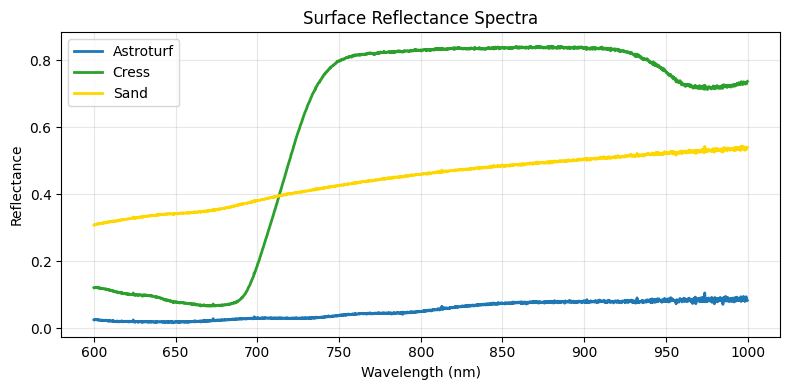

In [13]:
# Plot reflectance spectra for each target
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wavelength, rho_astroturf, label="Astroturf", linewidth=2, color=color_map["Astroturf"])
ax.plot(wavelength, rho_cress, label="Cress", linewidth=2, color=color_map["Cress"])
ax.plot(wavelength, rho_sand, label="Sand", linewidth=2, color=color_map["Sand"])
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.set_title("Surface Reflectance Spectra")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## *Step 5* - Propagate Uncertainties to Reflectance Spectra

With the reflectance spectra calculated, we now propagate the input uncertainties through the calibration model. This accounts for:
- **Random uncertainty** from repeated measurement noise (DN standard deviation for both surface and panel)
- **Systematic uncertainty** from the panel calibration certificate (magnitude is wavelength-dependent)

We use **punpy**'s Monte Carlo approach to combine these independent uncertainty sources.

In [14]:
# Initialise punpy's Monte Carlo propagation object with 10,000 iterations
prop = punpy.MCPropagation(10000)

# Propagate uncertainties through the reflectance model for each surface
# ASTROTURF
u_random_rho_astroturf = prop.propagate_random(
   reflectance_model,
   [dn_astroturf_mean, dn_panel_mean, rho_panel],
   [dn_astroturf_std, dn_panel_std, None]
)
u_syst_rho_astroturf = prop.propagate_systematic(
    reflectance_model,
        [dn_astroturf_mean, dn_panel_mean, rho_panel],
        [None, None, u_rho_panel]
)

# CRESS
u_random_rho_cress = prop.propagate_random(
   reflectance_model,
    [dn_cress_mean, dn_panel_mean, rho_panel],
    [dn_cress_std, dn_panel_std, None]
)
u_syst_rho_cress = prop.propagate_systematic(
    reflectance_model,
     [dn_cress_mean, dn_panel_mean, rho_panel],
     [None, None, u_rho_panel]
)

# SAND
u_random_rho_sand = prop.propagate_random(
   reflectance_model,
    [dn_sand_mean, dn_panel_mean, rho_panel],
    [dn_sand_std, dn_panel_std, None]
)
u_syst_rho_sand = prop.propagate_systematic(
    reflectance_model,
     [dn_sand_mean, dn_panel_mean, rho_panel],
     [None, None, u_rho_panel]
)

### Combining Uncertainties

Random and systematic uncertainties are independent error sources and should be combined in quadrature:

$$u_{\text{total}} = \sqrt{u_{\text{random}}^2 + u_{\text{systematic}}^2}$$

This gives the total combined uncertainty, which represents our best estimate of the measurement error from all sources.

In [15]:
# Calculate total uncertainty by combining random and systematic components
u_rho_astroturf = np.sqrt(u_random_rho_astroturf**2 + u_syst_rho_astroturf**2)
u_rho_cress = np.sqrt(u_random_rho_cress**2 + u_syst_rho_cress**2)
u_rho_sand = np.sqrt(u_random_rho_sand**2 + u_syst_rho_sand**2)


# Print summary statistics of uncertainties for each target
surfaces = {
    "Astro turf": (u_random_rho_astroturf, u_syst_rho_astroturf),
    "Cress": (u_random_rho_cress, u_syst_rho_cress),
    "Sand": (u_random_rho_sand, u_syst_rho_sand)
}

for surface, (u_random, u_syst) in surfaces.items():
    u_total = np.sqrt(u_random**2 + u_syst**2)
    print(f"\n{surface}:")
    print(f"  Random uncertainty:     mean={u_random.mean():.4e}, min={u_random.min():.4e}, max={u_random.max():.4e}")
    print(f"  Systematic uncertainty: mean={u_syst.mean():.4e}, min={u_syst.min():.4e}, max={u_syst.max():.4e}")
    print(f"  Total uncertainty:      mean={u_total.mean():.4e}, min={u_total.min():.4e}, max={u_total.max():.4e}")


Astro turf:
  Random uncertainty:     mean=4.5443e-03, min=1.3817e-03, max=1.1690e-02
  Systematic uncertainty: mean=1.2435e-03, min=2.4233e-04, max=2.7535e-03
  Total uncertainty:      mean=4.7191e-03, min=1.4140e-03, max=1.1944e-02

Cress:
  Random uncertainty:     mean=7.0095e-02, min=8.0509e-03, max=1.0162e-01
  Systematic uncertainty: mean=1.3826e-02, min=1.0217e-03, max=2.1940e-02
  Total uncertainty:      mean=7.1502e-02, min=8.1190e-03, max=1.0394e-01

Sand:
  Random uncertainty:     mean=2.7231e-02, min=8.7791e-03, max=4.3285e-02
  Systematic uncertainty: mean=9.7483e-03, min=4.7946e-03, max=1.4197e-02
  Total uncertainty:      mean=2.9229e-02, min=1.1021e-02, max=4.5459e-02


### Visualising Uncertainty Components

Now, we'll examine how the uncertainties vary across the spectrum. This helps us understand:
- Which wavelength regions have the largest errors?
- Does measurement noise (random) or calibration uncertainty (systematic) dominate?
- How do the uncertainties differ between surfaces?

Let's define plotting functions to visualise these components clearly.

In [16]:
# Define some helper functions to plot spectra with uncertainty
def plot_uncertainty_components(wavelength, u_random, u_syst, label, ax=None, percent=False, rho=None, ylim=None):
    """Plot random, systematic, and total uncertainty components."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3))
        show_plot = True
    else:
        show_plot = False

    if ylim is not None:
        ax.set_ylim(ylim)

    if percent:
        u_random = 100 * u_random / rho
        u_syst = 100 * u_syst / rho
    ax.plot(wavelength, u_random, label="Random uncertainty", linestyle='--', linewidth=0.5)
    ax.plot(wavelength, u_syst, label="Systematic uncertainty", linestyle='--', linewidth=0.7)
    ax.plot(wavelength, np.sqrt(u_random**2 + u_syst**2), label="Total uncertainty", linewidth=0.5)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Uncertainty in Reflectance (%)" if percent else "Uncertainty in Reflectance")
    ax.set_title(f"Uncertainty Components for {label}")
    ax.legend()
    if show_plot:
        plt.show()

def plot_spectrum_with_uncertainty(wavelength, rho, u_rho, label, ax=None, color='blue'):
    """Plot reflectance spectrum with ±1σ uncertainty band."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3))
        show_plot = True
    else:
        show_plot = False
   
    ax.plot(wavelength, rho, label=label, linewidth=2, color=color)
    ax.fill_between(wavelength, rho - u_rho, rho + u_rho, alpha=0.3, color=color)
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Reflectance")
    ax.legend()
   
    if show_plot:
        ax.set_title(f"{label} reflectance with uncertainty")
        plt.show()


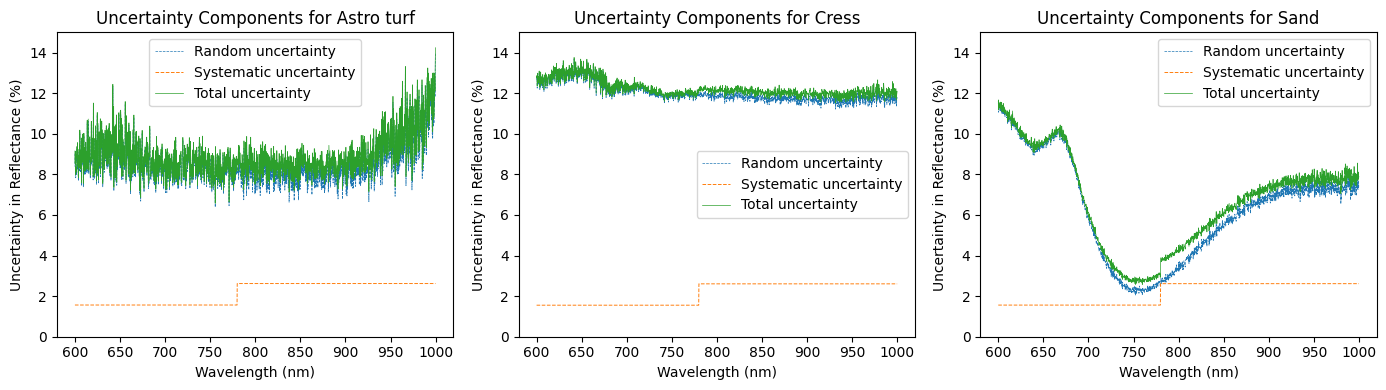

In [17]:
# Plot uncertainty components for each target as subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_uncertainty_components(wavelength, u_random_rho_astroturf, u_syst_rho_astroturf, "Astro turf", ax=axes[0], percent=True, rho=rho_astroturf, ylim=(0, 15))
plot_uncertainty_components(wavelength, u_random_rho_cress, u_syst_rho_cress, "Cress", ax=axes[1], percent=True, rho=rho_cress, ylim=(0, 15))
plot_uncertainty_components(wavelength, u_random_rho_sand, u_syst_rho_sand, "Sand", ax=axes[2], percent=True, rho=rho_sand, ylim=(0, 15))
plt.tight_layout()
plt.show()

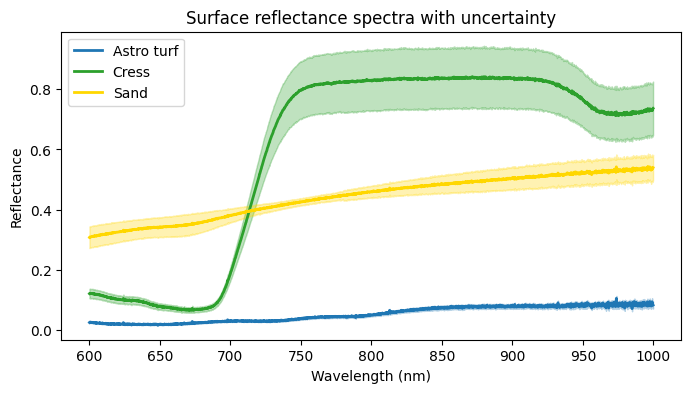

In [18]:
# Plot spectra with uncertainty for each target
fig, ax = plt.subplots(figsize=(8, 4))
plot_spectrum_with_uncertainty(wavelength, rho_astroturf, u_rho_astroturf, "Astro turf", ax=ax, color=color_map["Astroturf"])
plot_spectrum_with_uncertainty(wavelength, rho_cress, u_rho_cress, "Cress", ax=ax, color=color_map["Cress"])
plot_spectrum_with_uncertainty(wavelength, rho_sand, u_rho_sand, "Sand", ax=ax, color=color_map["Sand"])
ax.set_title("Surface reflectance spectra with uncertainty")
plt.show()

**❓Question**: If you repeated the measurements 1000 times instead of ~50, how would the random uncertainty in reflectance change? How would the systematic uncertainty change?

## *Step 6* - Band Integration and Uncertainty Propagation

The full reflectance spectra (and their uncertainties) from Step 5 are now ready to be transformed into satellite-compatible data products. Satellite vegetation indices like NDVI are not computed from full spectra but from specific spectral bands. 

We now integrate our measured reflectance spectra to red and near-infrared bands, propagating the accumulated uncertainties through this aggregation step.

### Band Integration Approach

This exercise uses **simplified band integration**—averaging reflectance within each band's wavelength range:
- **Red band:** 630–690 nm
- **NIR band:** 770–900 nm

In [19]:
# Calculate band-integrated reflectances for each surface
# ASTROTURF
rho_astroturf_red, rho_astroturf_nir = band_integrate(rho_astroturf, wavelength)

# CRESS
rho_cress_red, rho_cress_nir = band_integrate(rho_cress, wavelength)

# SAND
rho_sand_red, rho_sand_nir = band_integrate(rho_sand, wavelength)

# Display results
print("Band-integrated reflectance values:")
print(f"\n  Astro turf:")
print(f"    Red  (630–690 nm):  {rho_astroturf_red:.4f}")
print(f"    NIR  (770–900 nm):  {rho_astroturf_nir:.4f}")
print(f"\n  Cress:")
print(f"    Red  (630–690 nm):  {rho_cress_red:.4f}")
print(f"    NIR  (770–900 nm):  {rho_cress_nir:.4f}")
print(f"\n  Sand:")
print(f"    Red  (630–690 nm):  {rho_sand_red:.4f}")
print(f"    NIR  (770–900 nm):  {rho_sand_nir:.4f}")

Band-integrated reflectance values:

  Astro turf:
    Red  (630–690 nm):  0.0208
    NIR  (770–900 nm):  0.0644

  Cress:
    Red  (630–690 nm):  0.0776
    NIR  (770–900 nm):  0.8335

  Sand:
    Red  (630–690 nm):  0.3473
    NIR  (770–900 nm):  0.4757


The uncertainties are also propagated through this averaging operation, so the final band reflectances carry forward the spectrum-level uncertainties.

In [20]:
# Propagate uncertainties through band integration for each surface and band
# ASTRO TURF
u_random_rho_astroturf_red, u_random_rho_astroturf_nir = prop.propagate_random(
    band_integrate, [rho_astroturf, wavelength],
    [u_random_rho_astroturf, None]
)

u_syst_rho_astroturf_red, u_syst_rho_astroturf_nir = prop.propagate_systematic(
    band_integrate, [rho_astroturf, wavelength],
    [u_syst_rho_astroturf, None]
)

# CRESS
u_random_rho_cress_red, u_random_rho_cress_nir = prop.propagate_random(
    band_integrate, [rho_cress, wavelength],
    [u_random_rho_cress, None]
)
u_syst_rho_cress_red, u_syst_rho_cress_nir = prop.propagate_systematic(
    band_integrate, [rho_cress, wavelength],
    [u_syst_rho_cress, None]
)

# SAND
u_random_rho_sand_red, u_random_rho_sand_nir = prop.propagate_random(
    band_integrate, [rho_sand, wavelength],
    [u_random_rho_sand, None]
)
u_syst_rho_sand_red, u_syst_rho_sand_nir = prop.propagate_systematic(
    band_integrate, [rho_sand, wavelength],
    [u_syst_rho_sand, None]
)

print("Total uncertainties propagated through band integration:")
print(f"\n  Red band:   Astro turf = {np.sqrt(u_random_rho_astroturf_red**2 + u_syst_rho_astroturf_red**2 )*100/rho_astroturf_red:.2f} %,  Cress = {np.sqrt(u_random_rho_cress_red**2 + u_syst_rho_cress_red**2 )*100/rho_cress_red:.2f} %,  Sand = {np.sqrt(u_random_rho_sand_red**2 + u_syst_rho_sand_red**2 )*100/rho_sand_red:.2f} %")
print(f"  NIR band:   Astro turf = {np.sqrt(u_random_rho_astroturf_nir**2 + u_syst_rho_astroturf_nir**2 )*100/rho_astroturf_nir:.2f} %,  Cress = {np.sqrt(u_random_rho_cress_nir**2 + u_syst_rho_cress_nir**2 )*100/rho_cress_nir:.2f} %,  Sand = {np.sqrt(u_random_rho_sand_nir**2 + u_syst_rho_sand_nir**2 )*100/rho_sand_nir:.2f} %")


Total uncertainties propagated through band integration:

  Red band:   Astro turf = 1.66 %,  Cress = 1.74 %,  Sand = 1.68 %
  NIR band:   Astro turf = 2.59 %,  Cress = 2.57 %,  Sand = 2.58 %


**❓Question**: Compare the NDVI uncertainties across the three surfaces. Which has the largest total uncertainty and why? Does this change if we consider absolute uncertainties rather than relative (%)?

## *Step 7* - Calculate NDVI and Propagate Final Uncertainties

Now we compute the final NDVI value from the band-integrated red and NIR reflectances. NDVI is commonly used to assess vegetation health as it represents vegetation 'greenness' for a surface:
- **NDVI near +1:** Dense, healthy vegetation (high NIR, low red reflectance)
- **NDVI near 0:** Sparse vegetation or bare soil (moderate NIR and red reflectance)  
- **NDVI near –1:** Water or snow (low NIR, high red reflectance)


**❓Question**: Which surface do you predict will have the highest NDVI, and which the lowest?

Run the cell below to check your prediction against the actual data.

In [21]:
# Calculate NDVI for each target
ndvi_astroturf = ndvi_model(rho_astroturf_red, rho_astroturf_nir)
ndvi_cress = ndvi_model(rho_cress_red, rho_cress_nir)
ndvi_sand = ndvi_model(rho_sand_red, rho_sand_nir)

print(f"\nNDVI values:")
print(f"  Astro turf:  {ndvi_astroturf:.4f}")
print(f"  Cress:       {ndvi_cress:.4f}")
print(f"  Sand:        {ndvi_sand:.4f}")


NDVI values:
  Astro turf:  0.5112
  Cress:       0.8297
  Sand:        0.1559


The uncertainty in NDVI comes from the combined uncertainties in both bands, propagated through the NDVI formula. As before, this is performed separately for **random** and **systematic** uncertainty components:

**⚡Try this yourself**: Using the provided ndvi_model function and the uncertainty propagation tools, propagate the random and systematic uncertainties separately through the NDVI calculation for Astroturf, Cress and Sand. 

In [22]:
# Propagate uncertainties through the NDVI calculation
print("Propagating uncertainties through NDVI calculation...\n")

# Astro turf
u_random_ndvi_astroturf = prop.propagate_random(
    ndvi_model,
    [rho_astroturf_red, rho_astroturf_nir],
    [u_random_rho_astroturf_red, u_random_rho_astroturf_nir]
)
u_syst_ndvi_astroturf = prop.propagate_systematic(
    ndvi_model,
    [rho_astroturf_red, rho_astroturf_nir],
    [u_syst_rho_astroturf_red, u_syst_rho_astroturf_nir]
)

# Cress
u_random_ndvi_cress = prop.propagate_random(
    ndvi_model,
    [rho_cress_red, rho_cress_nir],
    [u_random_rho_cress_red, u_random_rho_cress_nir]
)
u_syst_ndvi_cress = prop.propagate_systematic(
    ndvi_model,
    [rho_cress_red, rho_cress_nir],
    [u_syst_rho_cress_red, u_syst_rho_cress_nir]
)

# Sand
u_random_ndvi_sand = prop.propagate_random(
    ndvi_model,
    [rho_sand_red, rho_sand_nir],
    [u_random_rho_sand_red, u_random_rho_sand_nir]
)
u_syst_ndvi_sand = prop.propagate_systematic(
    ndvi_model,
    [rho_sand_red, rho_sand_nir],
    [u_syst_rho_sand_red, u_syst_rho_sand_nir]
)

Propagating uncertainties through NDVI calculation...



The **Total** uncertainty combines both **systematic** and **random** sources of error and quantifies confidence in each NDVI estimate. This is calculated by adding both **systematic** and **random** components in quadrature, as before:

In [23]:
# Calculate total uncertainties by combining random and systematic components
u_total_ndvi_astroturf = np.sqrt(u_random_ndvi_astroturf**2 + u_syst_ndvi_astroturf**2)
u_total_ndvi_cress = np.sqrt(u_random_ndvi_cress**2 + u_syst_ndvi_cress**2)
u_total_ndvi_sand = np.sqrt(u_random_ndvi_sand**2 + u_syst_ndvi_sand**2)

# Summary of NDVI uncertainties
print("NDVI Uncertainties (absolute):")
print(f"\n  Astro turf:  Random = {u_random_ndvi_astroturf:.6f},  Systematic = {u_syst_ndvi_astroturf:.6f},  Total = {u_total_ndvi_astroturf:.6f}")
print(f"  Cress:       Random = {u_random_ndvi_cress:.6f},  Systematic = {u_syst_ndvi_cress:.6f},  Total = {u_total_ndvi_cress:.6f}")
print(f"  Sand:        Random = {u_random_ndvi_sand:.6f},  Systematic = {u_syst_ndvi_sand:.6f},  Total = {u_total_ndvi_sand:.6f}")

NDVI Uncertainties (absolute):

  Astro turf:  Random = 0.002413,  Systematic = 0.011028,  Total = 0.011289
  Cress:       Random = 0.001468,  Systematic = 0.004656,  Total = 0.004882
  Sand:        Random = 0.003082,  Systematic = 0.014737,  Total = 0.015056


## *Step 8* - Visualise and Compare NDVI Results

Finally, we compare NDVI across the three surfaces with their full uncertainty budgets. This allows us to:

1. **Interpret vegetation** - Different material types show different NDVI values
2. **Assess measurement confidence** - Larger error bars indicate higher uncertainty
3. **Compare uncertainty sources** - See how much comes from measurement noise vs. calibration

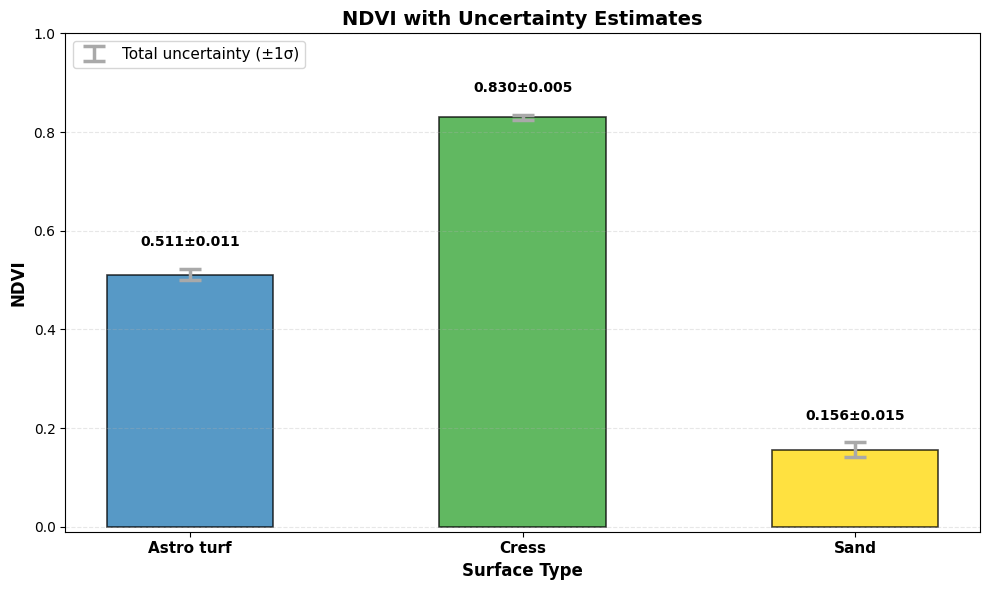


SUMMARY: NDVI Values and Uncertainties Across Surfaces
Surface         NDVI         Random Unc.        Systematic Unc.    Total Unc.  
-------------------------------------------------------------------------------------
Astro turf      0.5112       ±0.0024            ±0.0110            ±0.0113     
Cress           0.8297       ±0.0015            ±0.0047            ±0.0049     
Sand            0.1559       ±0.0031            ±0.0147            ±0.0151     


In [24]:
# Create visualisation comparing NDVI values with uncertainties
surfaces = ["Astro turf", "Cress", "Sand"]
ndvi_values = [ndvi_astroturf, ndvi_cress, ndvi_sand]
ndvi_uncertainties = [u_total_ndvi_astroturf, u_total_ndvi_cress, u_total_ndvi_sand]
u_random_values = [u_random_ndvi_astroturf, u_random_ndvi_cress, u_random_ndvi_sand]
u_syst_values = [u_syst_ndvi_astroturf, u_syst_ndvi_cress, u_syst_ndvi_sand]

# Create bar plot with error bars
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(surfaces))
width = 0.5

# Define colors for each surface
bar_colors = [color_map["Astroturf"], color_map["Cress"], color_map["Sand"]]

# Plot NDVI values as bars with surface-specific colors
bars = ax.bar(x_pos, ndvi_values, width, color=bar_colors, alpha=0.75, edgecolor='black', linewidth=1.2)

# Add error bars showing total uncertainty (±1σ)
ax.errorbar(x_pos, ndvi_values, yerr=ndvi_uncertainties, fmt="none", 
            ecolor="darkgray", capsize=8, capthick=2.5, elinewidth=2.5, label="Total uncertainty (±1σ)", zorder=3)

# Customize plot
ax.set_ylabel("NDVI", fontsize=12, fontweight="bold")
ax.set_xlabel("Surface Type", fontsize=12, fontweight="bold")
ax.set_title("NDVI with Uncertainty Estimates", fontsize=14, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(surfaces, fontsize=11, fontweight="bold")
ax.legend(fontsize=11, loc="upper left")
ax.grid(axis="y", alpha=0.3, linestyle="--", zorder=0)
ax.set_ylim(-0.01, 1.0)

# Add value labels on bars
for bar, val, unc in zip(bars, ndvi_values, ndvi_uncertainties):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + unc + 0.04,
            f"{val:.3f}±{unc:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*85)
print("SUMMARY: NDVI Values and Uncertainties Across Surfaces")
print("="*85)
print(f"{'Surface':<15} {'NDVI':<12} {'Random Unc.':<18} {'Systematic Unc.':<18} {'Total Unc.':<12}")
print("-"*85)
for surf, ndvi, u_rand, u_sys, u_tot in zip(
    surfaces, ndvi_values, u_random_values, u_syst_values, ndvi_uncertainties
):
    print(f"{surf:<15} {ndvi:<12.4f} ±{u_rand:<17.4f} ±{u_sys:<17.4f} ±{u_tot:<11.4f}")

## *Optional: Extension* — End-to-End Uncertainty Propagation

#### Why Combine Steps?

In the workflow above, we propagated uncertainties through three separate steps (calibration → bands → NDVI). An alternative is to **combine all operations into a single measurement function** that directly converts DN to NDVI:

$$\text{DN readings} \rightarrow \text{Reflectance calibration} \rightarrow \text{Band integration} \rightarrow \text{NDVI}$$

#### Advantages of the End-to-End Approach

- **Simpler workflow:** One propagation operation instead of three
- **Implicit correlation handling:** All relationships between steps are automatically captured
- **Computational efficiency:** Fewer intermediate calculations for large datasets
- **Cleaner code:** Fewer intermediate variables to manage

### Exercise

Write a single measurement function that takes raw DN measurements and returns final NDVI, incorporating all three models from Step 3. Then propagate uncertainties through this combined function in a single operation and compare your results with the step-by-step approach above.

In [25]:
# TODO: Define your end-to-end measurement function here
# This should combine all three modeling steps into a single function

def end_to_end_ndvi(dn_surface, dn_panel, rho_panel):
    """
    Calculate NDVI from raw spectrometer measurements in one integrated step.

    Combines reflectance calibration, band integration, and NDVI calculation.

    :param dn_surface: surface measurement digital numbers (shape: n_wavelengths)
    :param dn_panel: panel (Spectralon) measurement digital numbers (shape: n_wavelengths)
    :param rho_panel: panel reflectance spectrum (shape: n_wavelengths)
    :returns: Normalized Difference Vegetation Index (NDVI)
    """
    # Step 1: Calculate surface reflectance spectrum
    rho = reflectance_model(dn_surface, dn_panel, rho_panel)
    
    # Step 2: Band integrate to Sentinel-2 bands
    rho_red, rho_nir = band_integrate(rho, wavelength)
    
    # Step 3: Calculate NDVI
    ndvi = ndvi_model(rho_red, rho_nir)
    
    return ndvi

In [26]:
# TODO: Propagate uncertainties through the end-to-end NDVI function
# Compare results with the step-by-step approach used above

# Hints:
# 1. Which inputs have uncertainties? (DN measurements and panel reflectance)
# 2. Should you use propagate_random, propagate_systematic, or both?
# 3. Remember that uncertainties on inputs are already calculated earlier

# Example structure:
# u_random_ndvi_e2e = prop.propagate_random(
#     end_to_end_ndvi,
#     [...],  # input values
#     [...], # random uncertainties
# )
#
# u_syst_ndvi_e2e = prop.propagate_systematic(
#     end_to_end_ndvi,
#     [...],  # input values
#     [...] # systematic uncertainties
# )

# TODO: Implement uncertainty propagation for each surface
# (or all surfaces at once using loops)

**⚡Exercise**: Implement uncertainty propagation and compare approaches!
After propagation, compare:
 -  Does end-to-end propagation give the same results as step-by-step?
    - Why or why not?
    - Which approach is simpler? Which is more computationally efficient?

## 💡Key Takeaways

This exercise demonstrated how to propagate uncertainties through a complete measurement workflow. Here are the core principles to remember:

**1. Random and Systematic Uncertainties Behave Differently**
   - **Random uncertainties** arise from independent noise events (e.g., detector fluctuations). They are **uncorrelated** across replicate measurements and average out with repeated sampling.
   - **Systematic uncertainties** arise from biases that persist uniformly (e.g., calibration errors). They are **fully correlated** across all measurements and do not average out.
   - Both types must be propagated independently and combined in quadrature: $u_{\text{total}}^2 = u_{\text{random}}^2 + u_{\text{systematic}}^2$

**2. Uncertainties Propagate Through Measurement Chains**
   - Each processing step (calibration → band integration → NDVI) transforms both the measurand **and** its uncertainty.
   - Input uncertainties accumulate: NDVI uncertainty depends on DN measurement noise, panel calibration bias, and band integration averaging.
   - Understanding the measurement chain helps identify where uncertainties grow largest—often at critical transform steps like division or non-linear functions.

**3. End-to-End Propagation Offers Simplicity and Transparency**
   - Combining all steps into a single measurement function simplifies code and eliminates intermediate variable management.
   - Implicit correlation handling: **punpy** automatically captures all relationships between inputs without requiring explicit correlation matrices.
   - Trade-off: Step-by-step propagation offers more diagnostic insight into where uncertainties arise at each stage.

**4. Error Correlation Is Central to Metrology**
   - Treating correlated errors as independent, or vice versa, leads to incorrect uncertainty estimates—sometimes significantly over- or under-estimating true confidence.
   - Always ask: *Are my error sources independent realisations, or are they fully correlated across my dataset?*

# **🔗Link to next exercise**
We have now finished going over the uncertainty propagation methods with the example of raw spectrometer data to a vegetation index (NDVI). .

[Exercise 4](https://colab.research.google.com/github/comet-toolkit/comet_training/blob/main/CoMet_Training_Exercise4.ipynb), showcases how [**obsarray**](https://obsarray.readthedocs.io/en/latest/) can store error-correlation information – using the UNC specification- for multi-dimensional measurement datasets such as from Earth Observation.